In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("../../datasets/train.csv")
df.head()

,url,label,dots,at,equals,slashes,hyphens,colons,question_marks,digits,...,cte_domain,is_domain_ip,tld,is_tld_iana_reg,is_mtld,subdomains,special_chars,digit_to_length_ratio,char_to_length_ratio,specialchar_to_length_ratio
0,http://www.srilankan.com/en_uk/special-offers/...,0,2,0,4,5,5,1,1,23,...,3.75,0,com,1,0,1,6,0.10,0.73,0.03
1,https://www.vismaspcs.se/visma-support/visma-a...,0,3,0,0,7,6,1,0,4,...,3.77,0,se,1,0,1,0,0.03,0.85,0.00
2,https://www.mclarenstore.com/stores/mclaren/en...,0,2,0,0,7,0,1,0,0,...,4.04,0,com,1,0,1,0,0.00,0.82,0.00
3,http://eu.battle.net.blizzardenteaitaccoutmana...,1,5,0,0,3,0,1,0,2,...,5.45,0,com,1,0,3,0,0.03,0.83,0.00
4,http://ww0.chase.com.asp72.com/ccp/clientconfi...,1,5,0,1,5,0,1,1,5,...,3.97,0,com,1,0,3,0,0.06,0.79,0.00


In [3]:
def get_pca_data(threshold):
    k = np.argmax(cumulative_variance >= threshold) + 1
    print(f"Number of components to retain {int(threshold*100)}% variance:", k)
    top_k_eigvecs = eig_vecs[:, :k]
    X_pca = X_scaled.dot(top_k_eigvecs)
    df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(k)])
    df_pca['label'] = y.values
    return df_pca

In [5]:
y = df["label"]

X = df.drop(columns=["url", "label", "tld"])
X = X.select_dtypes(include=["number"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

cov_matrix = np.cov(X_scaled, rowvar=False)
print(cov_matrix.shape)

eig_vals, eig_vecs = np.linalg.eig(cov_matrix)
sorted_index = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sorted_index]
eig_vecs = eig_vecs[:, sorted_index]

explained_variance_ratio = eig_vals / np.sum(eig_vals)
cumulative_variance = np.cumsum(explained_variance_ratio)

df_pca_90 = get_pca_data(0.90)
df_pca_90.to_csv("df_pca_90.csv", index=False)
print("Saved PCA dataset with 90% variance as 'df_pca_90.csv'")

df_pca_95 = get_pca_data(0.95)
df_pca_95.to_csv("df_pca_95.csv", index=False)
print("Saved PCA dataset with 95% variance as 'df_pca_95.csv'")

(37, 37)
Number of components to retain 90% variance: 19
Saved PCA dataset with 90% variance as 'df_pca_90.csv'
Number of components to retain 95% variance: 22
Saved PCA dataset with 95% variance as 'df_pca_95.csv'


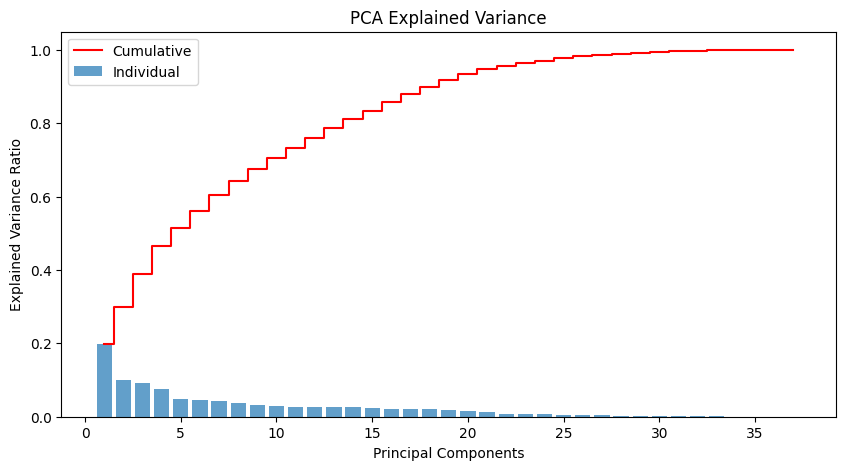

C:\Users\swaya\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


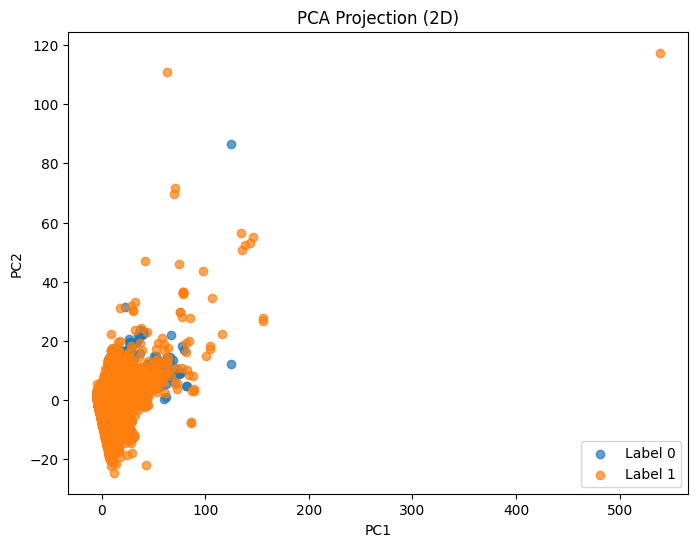

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(range(1, len(explained_variance_ratio)+1), explained_variance_ratio, alpha=0.7, label='Individual')
plt.step(range(1, len(cumulative_variance)+1), cumulative_variance, where='mid', label='Cumulative', color='red')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')
plt.legend()
plt.show()

if X_pca.shape[1] >= 2:
    plt.figure(figsize=(8,6))
    for label in np.unique(y):
        plt.scatter(
            X_pca[y==label, 0], 
            X_pca[y==label, 1], 
            label=f"Label {label}", alpha=0.7
        )
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA Projection (2D)')
    plt.legend()
    plt.show()
else:
    print("Not enough components for 2D scatter plot.")

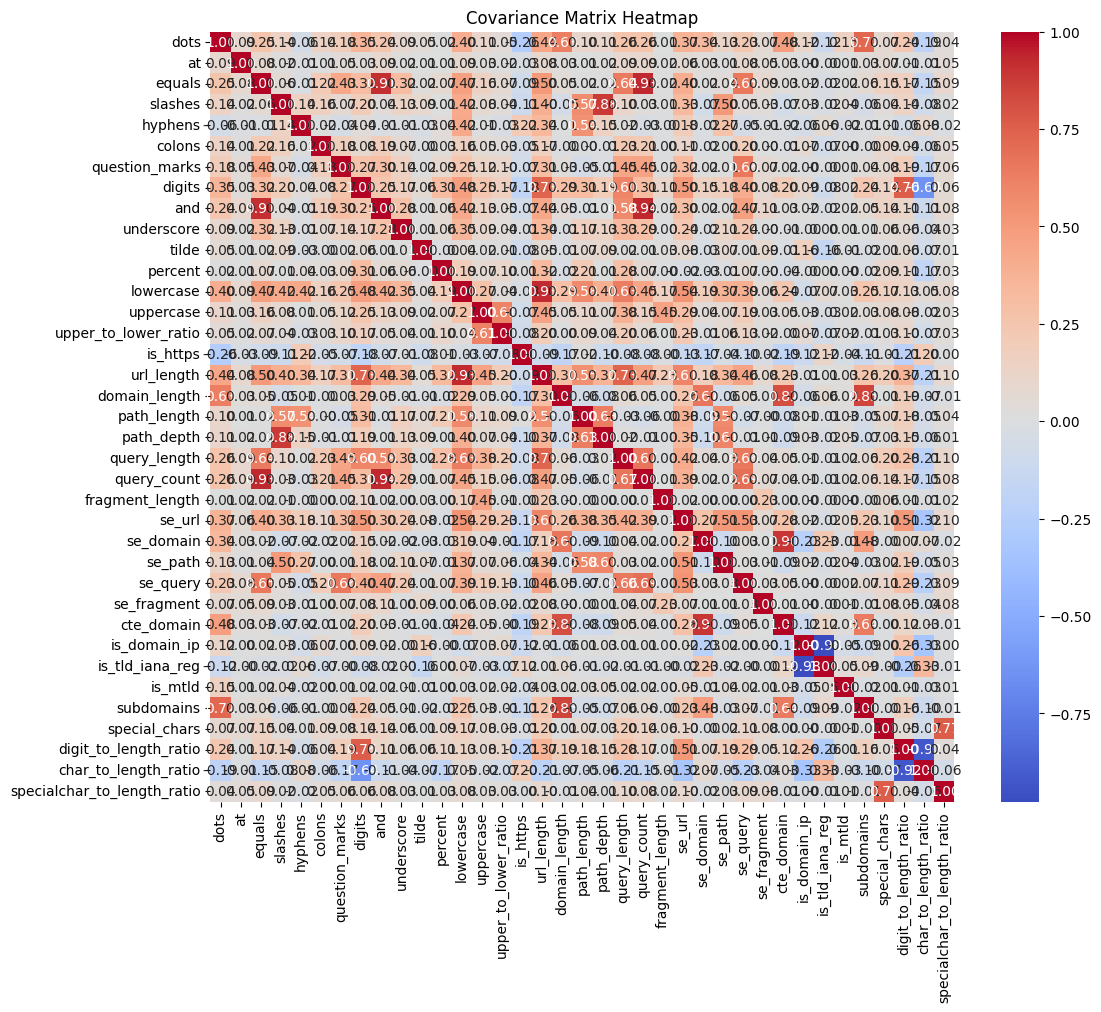

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(cov_matrix, annot=True, fmt=".2f", cmap="coolwarm", xticklabels=X.columns, yticklabels=X.columns)
plt.title("Covariance Matrix Heatmap")
plt.show()